In [1]:
def spectral_diagnostics(psd, f, f_cutoff=None):
    """
    Function for computing spectral moments, bandwidth, and entropy.
    This acts as a diagnostic tool to connect PSD shape to decorrelation scales.
    
    Parameters
    ----------
    psd : Power spectral density array (from spectrum1D_frequency).
    f : Frequency vector (from spectrum1D_frequency).
    f_cutoff : Frequency to split 'low' (mesoscale) and 'high' (tidal) bands.
    
    Returns
    -------
    m : Array of moments [m0, m1, m2].
    nu : Spectral bandwidth parameter (dimensionless).
    skew : Spectral skewness (measures asymmetry of energy distribution).
    entropy : Spectral entropy (measure of complexity).
    ratio : If f_cutoff is provided, returns ratio of low-freq to high-freq variance.
    """

    # Import libraries
    import numpy as np

    ###########################################################################
    ## STEP #1 - Compute global spectral moments (m0, m1, m2)
    ###########################################################################
    # m0 is the zeroth moment (total variance)
    m0 = np.trapezoid(psd, f)
    
    # m1 is the first moment (centroid / mean frequency)
    m1 = np.trapezoid(f * psd, f)
    
    # m2 is the second moment (spectral spread / inertia)
    m2 = np.trapezoid((f**2) * psd, f)
    
    # m3: Third moment (Asymmetry / Tail weight)
    m3 = np.trapezoid((f**3) * psd, f)
    
    # Combine into a moments array
    m = np.array([m0, m1, m2, m3])

    ###########################################################################
    ## STEP #2 - Compute Spectral Bandwidth (nu) and Skewness (gamma)
    ###########################################################################
    # Bandwidth represents the spread of energy around the mean frequency
    # nu ~ 0 for narrow-band (tides), nu > 1 for broad-band (turbulence)
    if m1 > 0:
        nu = np.sqrt(np.abs((m0 * m2) / (m1**2) - 1))

        # Spectral Skewness: Normalized 3rd moment around the mean frequency (m1/m0)
        f_mean = m1 / m0
        sigma_f = np.sqrt(np.abs((m2 / m0) - f_mean**2)) # Spectral standard deviation
        
        # Integrate (f - f_mean)^3 * PSD
        m3_central = np.trapezoid(((f - f_mean)**3) * psd, f)
        skew = m3_central / (m0 * sigma_f**3) if sigma_f > 0 else 0

    else:
        nu = np.nan
        skew = np.nan

    ###########################################################################
    ## STEP #3 - Compute Spectral Entropy (Hs)
    ###########################################################################
    # Normalize PSD to a probability distribution
    psd_norm = psd / np.sum(psd)
    
    # Mask out zeros to avoid log errors
    psd_norm = psd_norm[psd_norm > 0]
    
    # Compute Shannon Entropy
    entropy = -np.sum(psd_norm * np.log(psd_norm))

    ###########################################################################
    ## STEP #4 - Compute Partitioned Variance Ratio (Optional)
    ###########################################################################
    ratio = np.nan
    
    if f_cutoff is not None:
        # Create masks for frequency ranges
        low_mask = f <= f_cutoff
        high_mask = f > f_cutoff
        
        # Integrate variance in each band
        var_low = np.trapezoid(psd[low_mask], f[low_mask])
        var_high = np.trapezoid(psd[high_mask], f[high_mask])
        
        # Compute ratio (Mesoscale energy vs Tidal/Internal wave energy)
        if var_high > 0:
            ratio = var_low / var_high

    return m, nu, skew, entropy, ratio

In [2]:
#--- 1D Power Spectrum with the Welch Method ---# 
def spectrum1D_frequency(data, dt, M, units):

    """
    Function for computing the 1D power density spectrum with the Welch method.
    This function is written notationally for time series, but can be applied to spatial data.
    The 1D frequency spectrum is computed by Hanning windowing segments of the data array with 50% overlap.
    
    Parameters
    ----------
    data : Time or spatial data series. Data must be evenly spaced (NaNs must be interpolated).
    dt : Time or spatial interval between measurements.
    M : Number of windows.
    units : 'Hz' (cyclical frequency) or 'rad/s' (radian frequency).
    
    Returns
    -------
    psd : Normalized power spectral density function.
    f : Frequency in units specified by units variable.
    CI : 95% confidence interval.
    variance : Array containing the variance in the time and frequency domains such that variance = np.array([time_domain, frequency_domain])
    """

    # Import libraries
    import numpy as np
    from spectra import spectral_uncer
    from scipy.signal.windows import hann
    from scipy.signal import detrend

    ###########################################################################
    ## STEP #1 - Set fundamental parameters for computing spectrum
    ###########################################################################
    N = len(data)                 # Number of data points of entire time series
    p = N // M                    # Number of data points within a window

    # Compute frequency resolution
    if units == 'Hz':
        df = 1 / (p * dt)
    elif units == 'rad/s':
        df = 2 * np.pi / (p * dt)

    # Compute number of positive frequencies
    if p % 2 == 0:
        L = p // 2 + 1
    else:
        L = (p - 1) // 2

    # Compute the period of the fundamental frequency (lowest frequency)
    T = p * dt

    # Compute frequency vector (units: Hz or rad/s)
    if p % 2 == 0:
        if units == 'Hz':
            f = (1 / T) * np.arange(0, p // 2 + 1)
        elif units == 'rad/s':
            f = (2 * np.pi / T) * np.arange(0, p // 2 + 1)
    else:
        if units == 'Hz':
            f = (1 / T) * np.arange(0, (p - 1) // 2)
        elif units == 'rad/s':
            f = (2 * np.pi / T) * np.arange(0, (p - 1) // 2)

    ###########################################################################
    ## STEP #2 - Segment data with 50% overlap
    ###########################################################################

    # Compute number of segments including 50% overlap
    nseg = M + M - 1     

    # Initialize array for splitting time series into windows with 50% overlap
    data_seg_n = data[:M*p].reshape((p, M), order='F')  # Segment original data set
    data_seg_50 = []

    # Loop through segments
    for iseg in range(M - 1):

        # Obtain segment indicies
        ind_i = int(p * iseg + (p / 2))
        ind_f = int(ind_i + p)

        # Index data and append
        if ind_f <= len(data):
            data_seg_50.append(data[ind_i:ind_f])

    # Concatinate data segements
    if data_seg_50:
        data_seg_50 = np.stack(data_seg_50, axis=1)
        data_seg_n = np.concatenate((data_seg_n, data_seg_50), axis=1)

    ###########################################################################
    ## STEP #3 - Remove linear trend for each segment and apply hanning window
    ###########################################################################

    # Compute a normalized hanning window
    window = hann(p) * np.sqrt(p / np.sum(hann(p)**2))

    # Preallocate windowed detrended segmented data array
    data_seg_w = np.zeros_like(data_seg_n)

    # Loop through segments
    for iseg in range(nseg):

        # Detrend and apply window
        data_seg_w[:, iseg] = detrend(data_seg_n[:, iseg]) * window

    ###########################################################################
    ## STEP #4 - Compute mean 1D frequency spectrum
    ###########################################################################

    # Preallocate arrays
    spec_sum = np.zeros(p)                 # Sspectrum summation array
    cn = np.zeros(p)                       # Counter
    variance = np.zeros(2)                 # Variance in time and frequency domain

    # Loop through segments
    for iseg in range(nseg):

        # Fourier transform data
        fft_data_seg = np.fft.fft(data_seg_w[:, iseg])         

        # Compute amplitudes
        amp = np.abs(fft_data_seg)**2                        

        # Normalize amplitudes
        amp_norm = amp / (p**2) / df                            

        # Compute variance in the time domain for each segment
        var_seg_time = np.var(data_seg_w[:, iseg])    

        # Sum spectrum 
        spec_sum += amp_norm                                   

        # Reinitialize counter
        cn += 1                                                 

    # Compute the mean spectrum 
    m_spec = spec_sum / cn        

    # Compute the mean variance across segments in the time domain
    variance[0] = np.mean(var_seg_time)                               

    # Grab positive frequencies
    psd = m_spec[:L]                                            

    # Double the amplitude for positive frequencies to conserve variance
    if N % 2 == 0:
        psd[1:-1] *= 2
    else:
        psd[1:] *= 2

    # Compute the variance in frequency space
    variance[1] = np.trapezoid(psd, f)

    # Compute 95% confidence interval
    _, CI, _ = spectral_uncer(M, 0.05, psd, 'data')

    return psd, f, CI, variance

--- Spectral Diagnostic Results ---
Total Variance (m0):     2.0344
Mean Frequency (m1):     3.8703 cycles/day
Skewness (gamma):        -1.1880
Bandwidth (nu):          0.1370
Spectral Entropy:        0.9979
Meso/Tidal Ratio:        0.0188


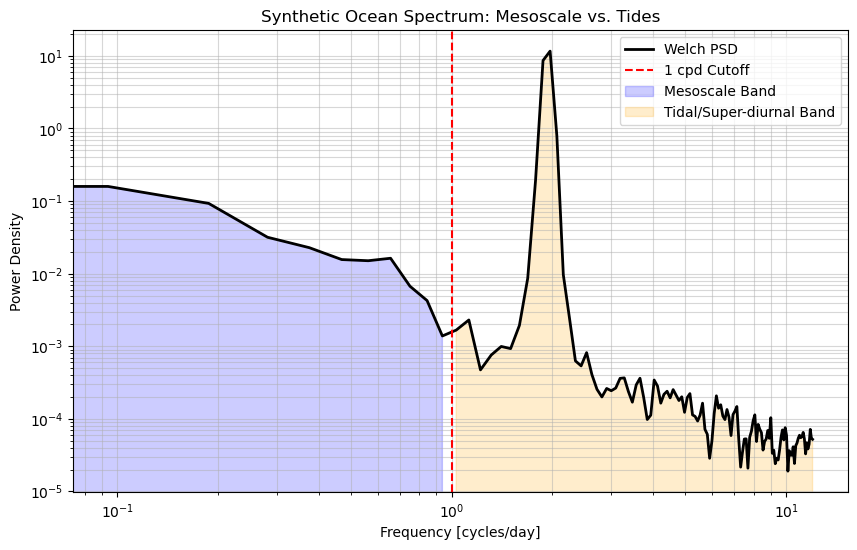

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

# --- Simulated Test Script --- #

# 1. Setup time parameters (32 days, 1-hour sampling)
dt = 1/24                       # 1 hour in days
T_total = 32                    # Total days
t = np.arange(0, T_total, dt)   # Time vector
N = len(t)

# 2. Generate Synthetic Ocean Data (Split Spectrum)
# Component A: Low-frequency Mesoscale (Red Noise)
# We use a random walk/integrated noise for "memory"
low_freq_noise = np.cumsum(np.random.normal(0, 1, N)) * 0.05

# Component B: High-frequency Tides (e.g., M2 tide ~12.42 hours)
# 12.42 hours is approx 1.93 cycles per day
tide_freq = 24 / 12.42 
tides = 2 * np.sin(2 * np.pi * tide_freq * t)

# Combine components (Surface-like: high noise; Deep-like: more organized)
data = low_freq_noise + tides

# 3. Compute PSD using your existing function
# (Assuming spectrum1D_frequency and spectral_diagnostics are defined)
M = 3 # Your specific windowing choice
psd, f, CI, variance = spectrum1D_frequency(data, dt, M, 'Hz')

# 4. Compute Spectral Diagnostics
# We set f_cutoff to 1.0 cpd to separate mesoscale from tides
f_cutoff = 1.0
m, nu, skew, entropy, ratio = spectral_diagnostics(psd, f, f_cutoff)

###########################################################################
## STEP #5 - Print and Visualize Results
###########################################################################

print("--- Spectral Diagnostic Results ---")
print(f"Total Variance (m0):     {m[0]:.4f}")
print(f"Mean Frequency (m1):     {m[1]:.4f} cycles/day")
print(f"Skewness (gamma):        {skew:.4f}")
print(f"Bandwidth (nu):          {nu:.4f}")
print(f"Spectral Entropy:        {entropy:.4f}")
print(f"Meso/Tidal Ratio:        {ratio:.4f}")

# Plotting the "Split" Behavior
plt.figure(figsize=(10, 6))
plt.loglog(f, psd, label='Welch PSD', color='black', lw=2)
plt.axvline(f_cutoff, color='red', linestyle='--', label='1 cpd Cutoff')

# Highlight the two regimes
plt.fill_between(f, psd, where=(f <= f_cutoff), color='blue', alpha=0.2, label='Mesoscale Band')
plt.fill_between(f, psd, where=(f > f_cutoff), color='orange', alpha=0.2, label='Tidal/Super-diurnal Band')

plt.xlabel('Frequency [cycles/day]')
plt.ylabel('Power Density')
plt.title('Synthetic Ocean Spectrum: Mesoscale vs. Tides')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [9]:
variance[1]

np.float64(0.1711967979901447)

In [4]:
m

array([ 2.03444517,  3.87033462,  7.50111843, 14.75312404])